<a href="https://colab.research.google.com/github/zen-code11/GC-Data/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/combined_data(2025-3-1-2026-2-28) by user.csv')
df1 = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/video_list_data_obfuscated.csv')
df2 = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/monthly-chart.csv')
df3 = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/month-wise-duration.csv')
df4 = pd.read_csv('/content/drive/MyDrive/Frammer GC dataset/combined_data(2025-3-1-2026-2-28) by output type.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df

,User,Uploaded Count,Created Count,Published Count,Uploaded Duration (hh:mm:ss),Created Duration (hh:mm:ss),Published Duration (hh:mm:ss)
0,Chandan,489,2152,19,100:43:58,209:18:47,01:13:40
1,QA-Purushottam,309,1227,13,33:08:48,55:19:21,00:21:34
2,vikas.s@moolya.com,265,1094,4,61:22:20,101:55:47,00:15:23
3,Sandeep Belaki,253,1039,7,39:59:44,84:32:25,00:08:12
4,Nitesh,224,959,0,59:57:41,87:54:11,00:00:00
5,Abhishek,201,408,8,19:25:46,26:56:37,00:25:04
6,Auto Upload,185,220,0,41:52:06,42:52:30,00:00:00
7,Subhesh,184,489,7,21:36:47,30:19:43,00:13:00
8,Trivendra,179,825,3,61:09:11,111:06:20,00:10:00
9,Dheeraj Pareek(QA theveritycorp.com),166,482,2,16:07:52,32:23:39,00:02:13


In [5]:
df.isnull().sum() #checking if any data is missing or not

,0
User,0
Uploaded Count,0
Created Count,0
Published Count,0
Uploaded Duration (hh:mm:ss),0
Created Duration (hh:mm:ss),0
Published Duration (hh:mm:ss),0


In [6]:
df.shape #dimensions of the dataform

(45, 7)

In [7]:
df.dtypes #checking the datatypes of each column


,0
User,object
Uploaded Count,int64
Created Count,int64
Published Count,int64
Uploaded Duration (hh:mm:ss),object
Created Duration (hh:mm:ss),object
Published Duration (hh:mm:ss),object


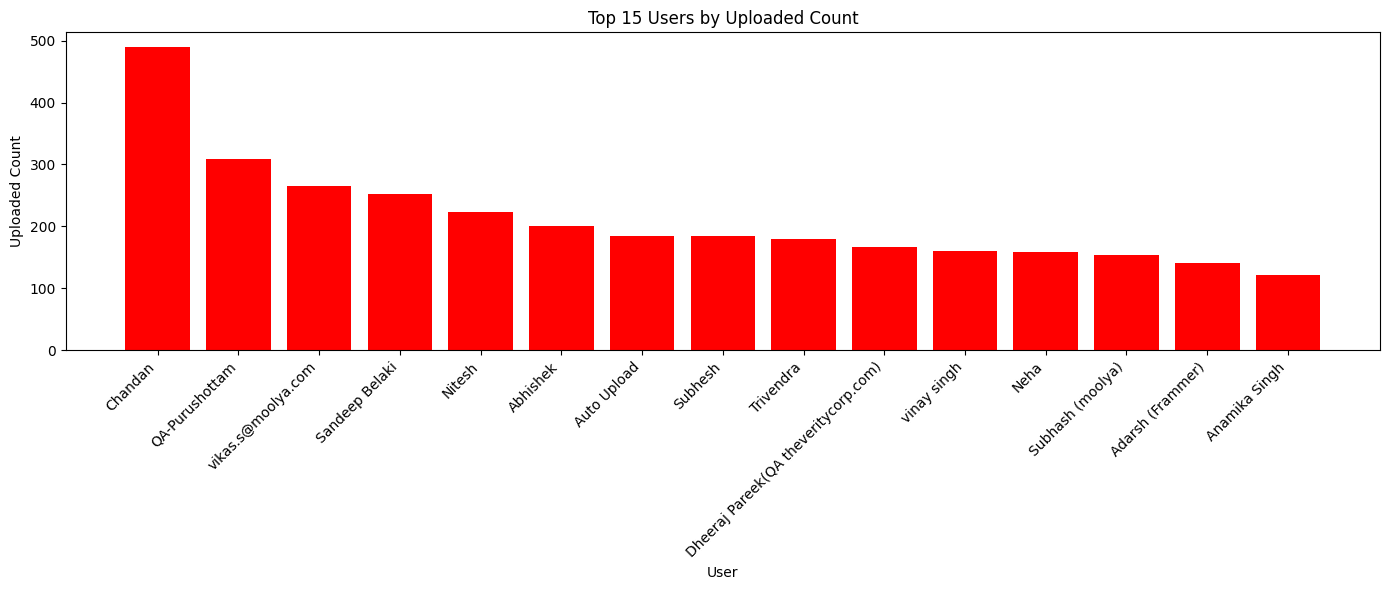

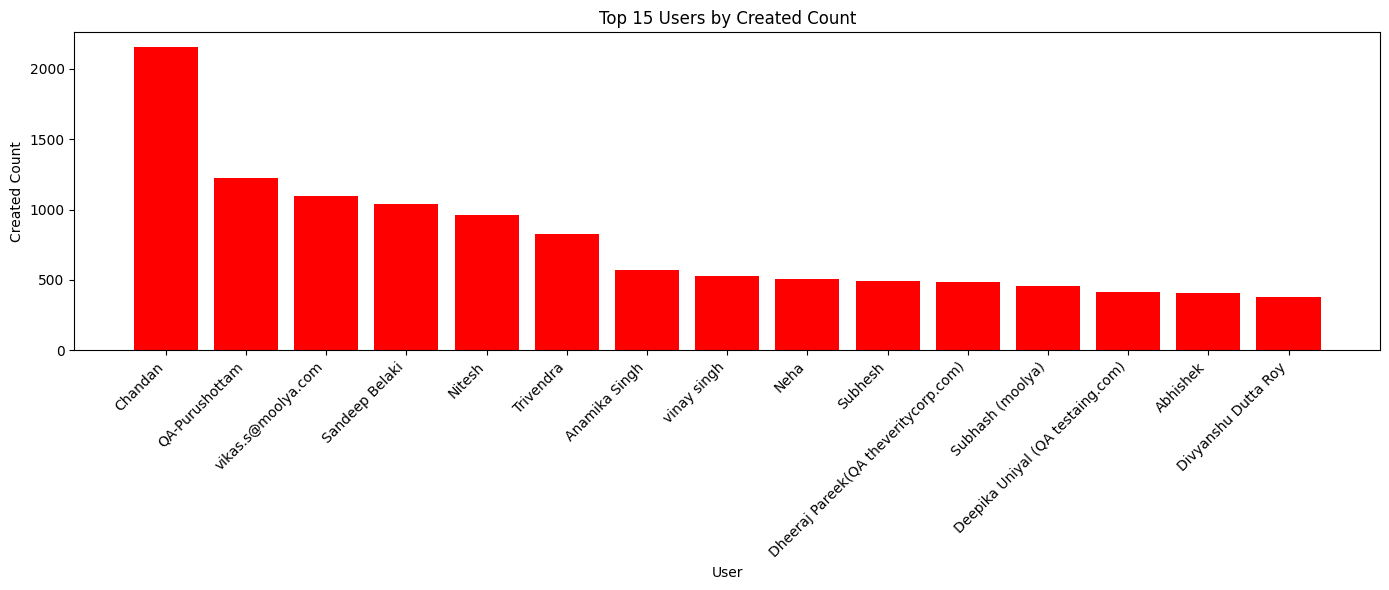

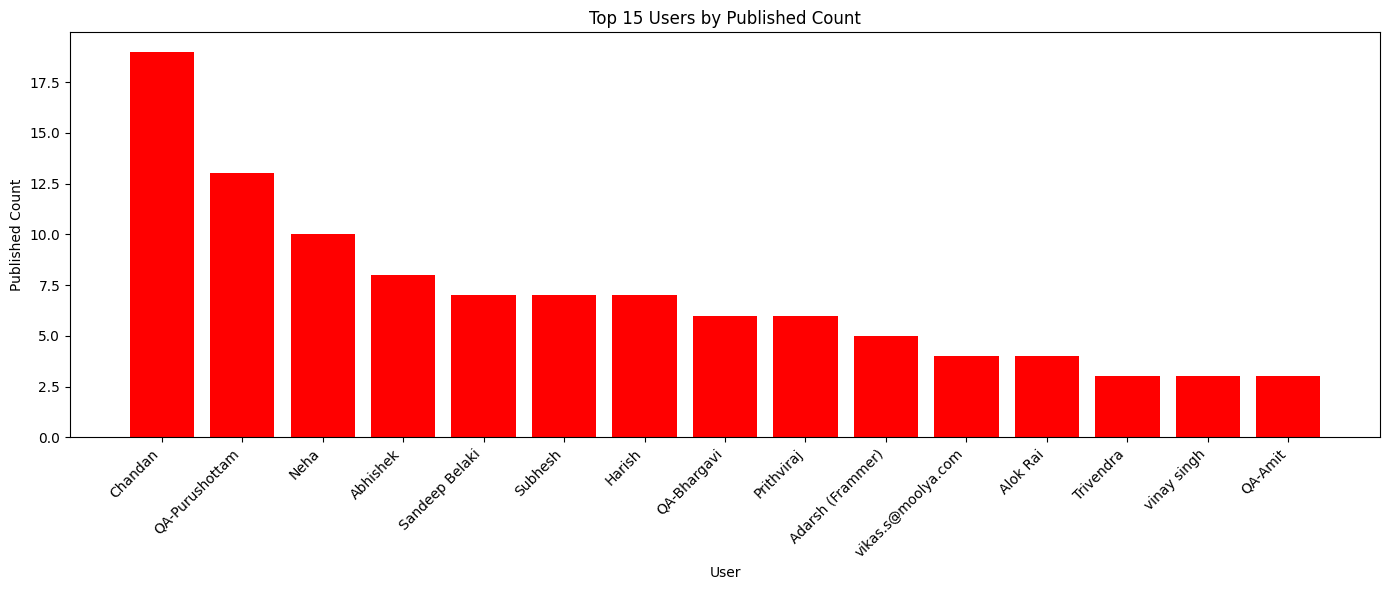

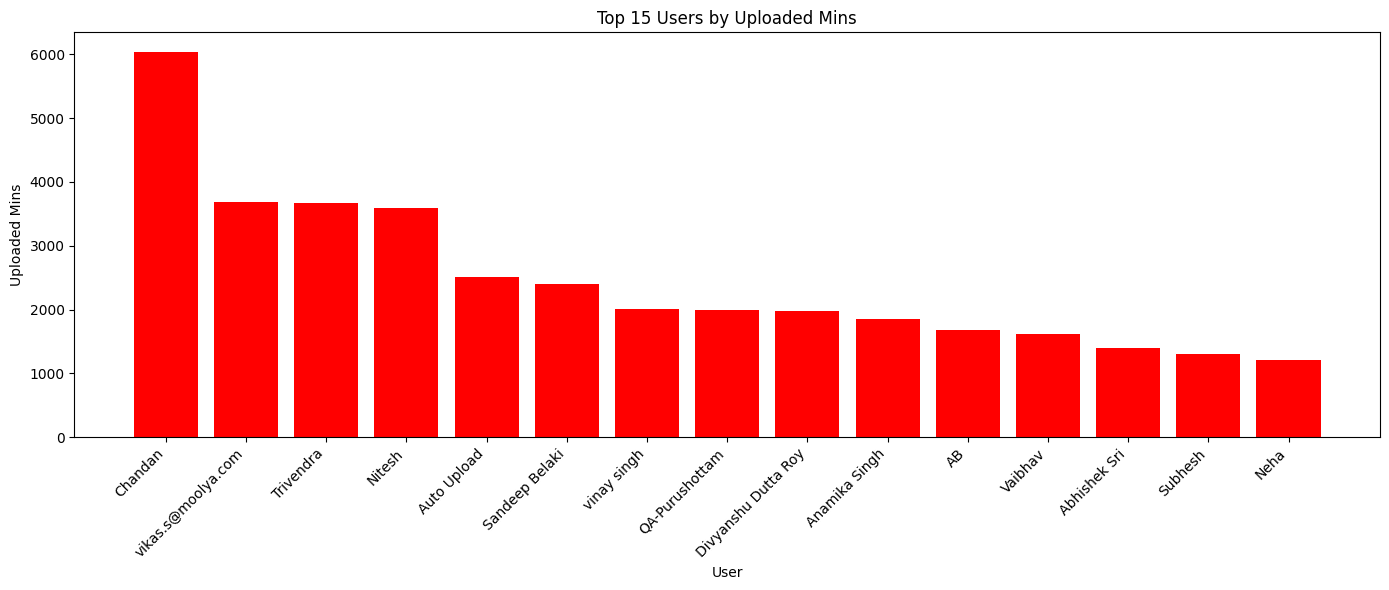

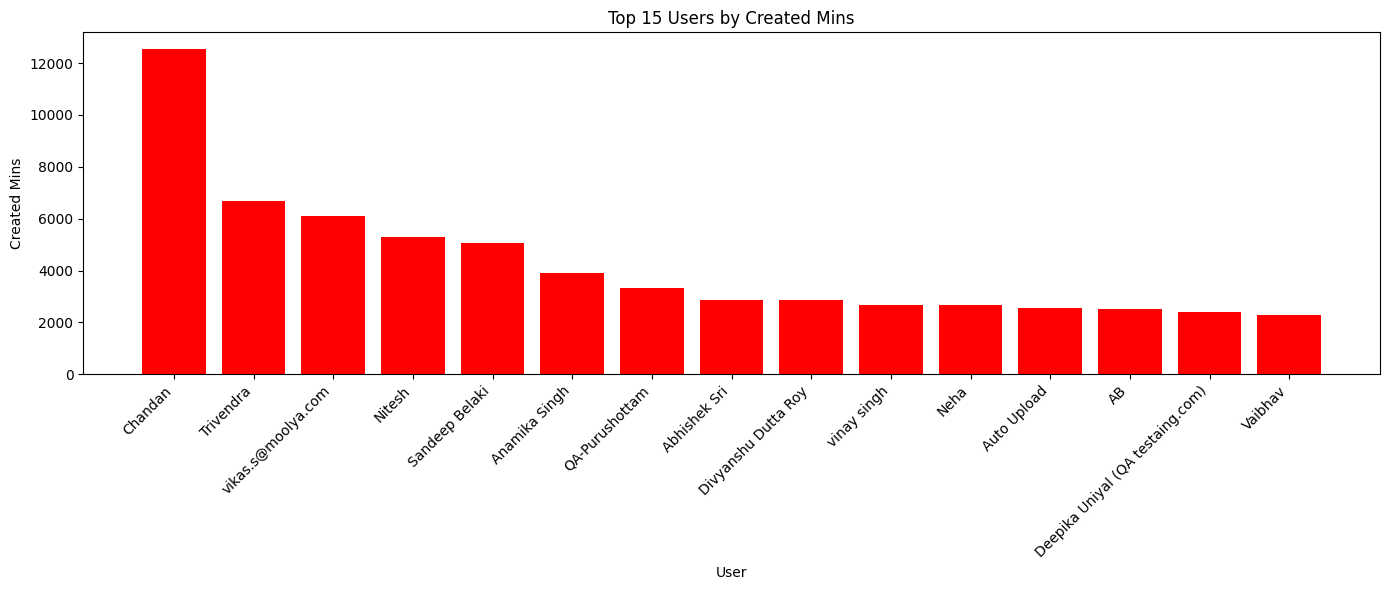

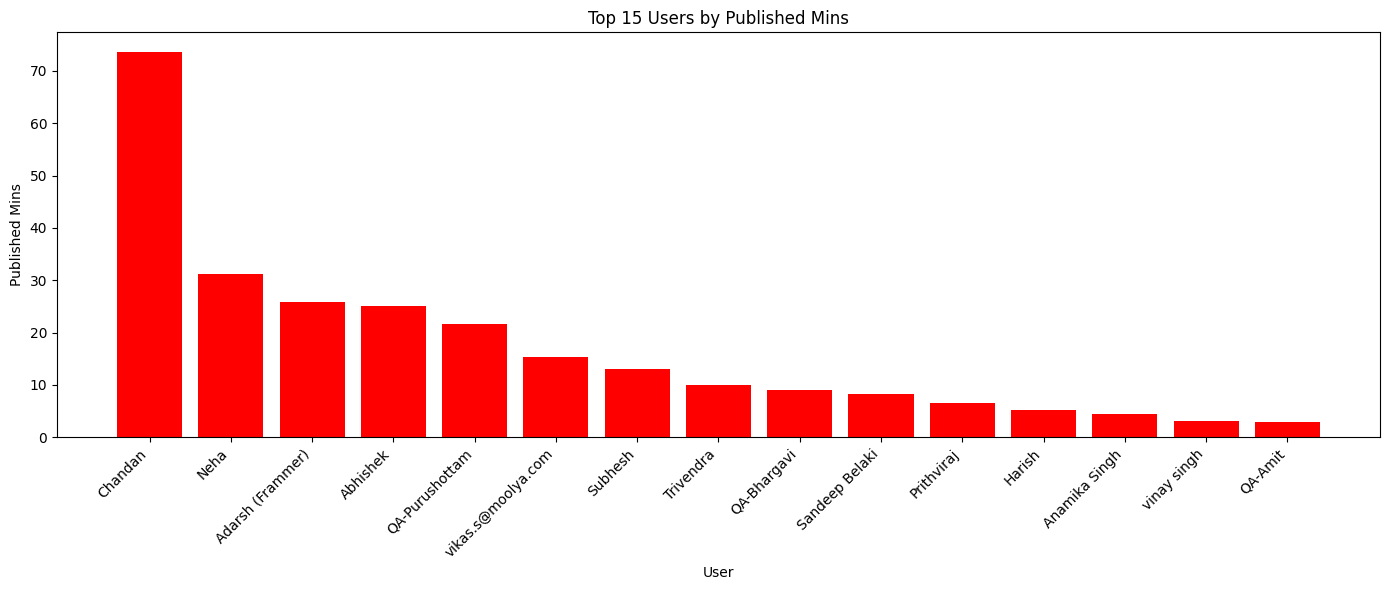

In [8]:
#we have to convert the duration which is in object form to numeric values
def to_minutes(t):
    try:
        h, m, s = str(t).strip().split(':')
        return int(h)*60 + int(m) + int(s)/60
    except:
        return 0

#passing the function for converting mins for object to int64 in mins
df['Uploaded Mins'] = df['Uploaded Duration (hh:mm:ss)'].apply(to_minutes)
df['Created Mins'] = df['Created Duration (hh:mm:ss)'].apply(to_minutes)
df['Published Mins'] = df['Published Duration (hh:mm:ss)'].apply(to_minutes)

# Converting count columns to numeric
df['Uploaded Count'] = pd.to_numeric(df['Uploaded Count'])
df['Created Count'] = pd.to_numeric(df['Created Count'])
df['Published Count'] = pd.to_numeric(df['Published Count'])

#function to plot those six columns in y-axis vs users in x-axis
def plot_top15(df, column, color='red'):
    top15 = df.nlargest(15, column)

    plt.figure(figsize=(14, 6))
    plt.bar(top15['User'], top15[column], color=color)
    plt.title(f'Top 15 Users by {column}')
    plt.xlabel('User')
    plt.ylabel(column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

columns = ['Uploaded Count', 'Created Count', 'Published Count',
           'Uploaded Mins', 'Created Mins', 'Published Mins']

for col in columns:
    plot_top15(df, col)


From these bar graphs we understand that more or less these bar graphs have correlation that some names perform the same way in all the columns now we will observe it to what scale they are related to each other.

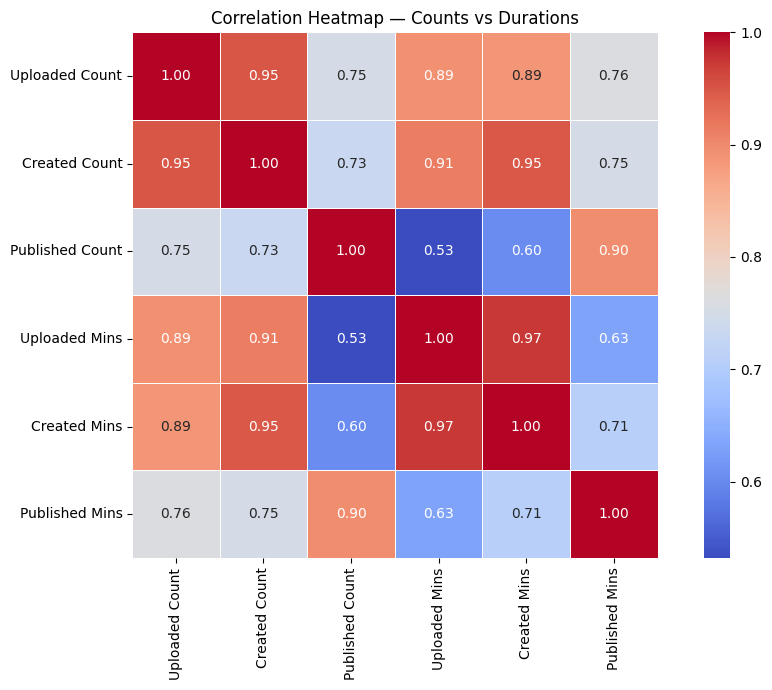

In [ ]:
corr_df = df[['Uploaded Count', 'Created Count', 'Published Count',
              'Uploaded Mins', 'Created Mins', 'Published Mins']]

#here we use the library seaborn to find correlation between these six columns
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Counts vs Durations')
plt.tight_layout()
plt.show()

We can say that there is high correlation between creating and uploading but when we take publishing into account we cannot say the same thing.
Looking at the correlation map we can see there is almost 20% gap between uploaded,created count with published count but when we see the same in mins the gap is almost 35%.

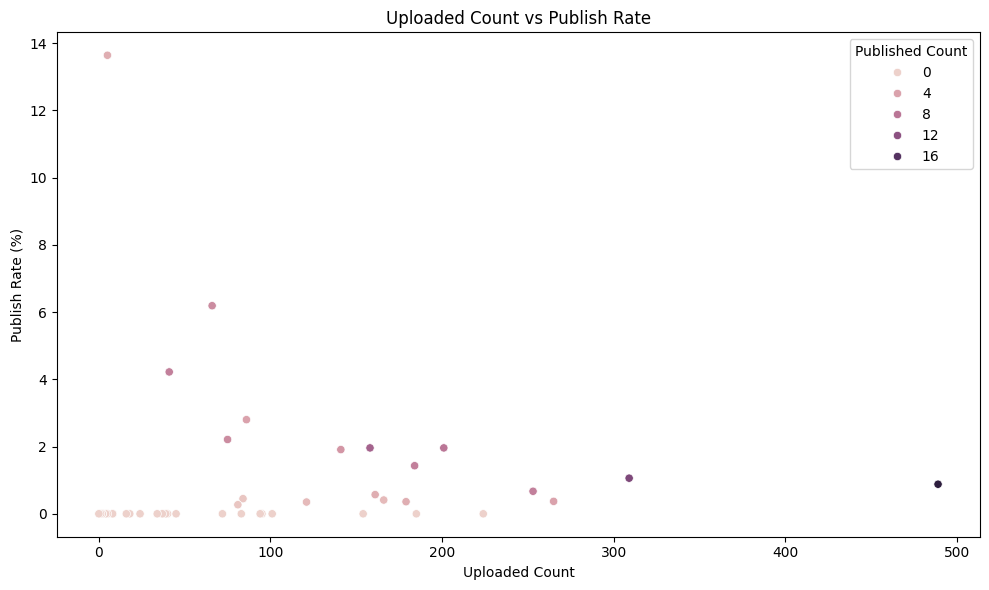

In [9]:
df['Publish Rate (%)'] = (df['Published Count'] / df['Created Count'] * 100).round(2) #calculating the publish percentage

plt.figure(figsize=(10,6)) #scatter plot with uploaded count on x-axis, publish rate on y-axis and the color/hue depicting the published count
sns.scatterplot(data=df, x='Uploaded Count', y='Publish Rate (%)', hue='Published Count')
plt.title('Uploaded Count vs Publish Rate')
plt.tight_layout()
plt.show()

Looking at the scatter plot of Uploaded Count vs Published Rate we come to know that actually there is no strong relation between them. If uploading more videos automatically meant better publishing, the dots would climb upward diagonally which is not the case here.

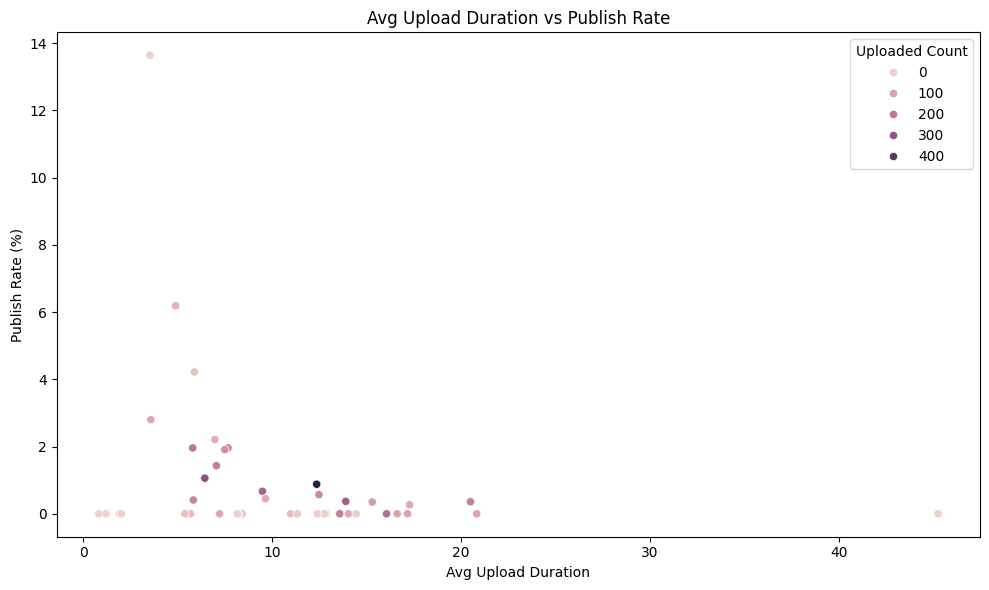

In [10]:
df['Avg Upload Duration'] = (df['Uploaded Mins'] / df['Uploaded Count']).round(2)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Avg Upload Duration', y='Publish Rate (%)', hue='Uploaded Count')
plt.title('Avg Upload Duration vs Publish Rate')
plt.tight_layout()
plt.show()

Same way we cannot say that users who upload longer videos publish more. We can even see that there are points with less average upload duration but more publish rate compared to longer videos.

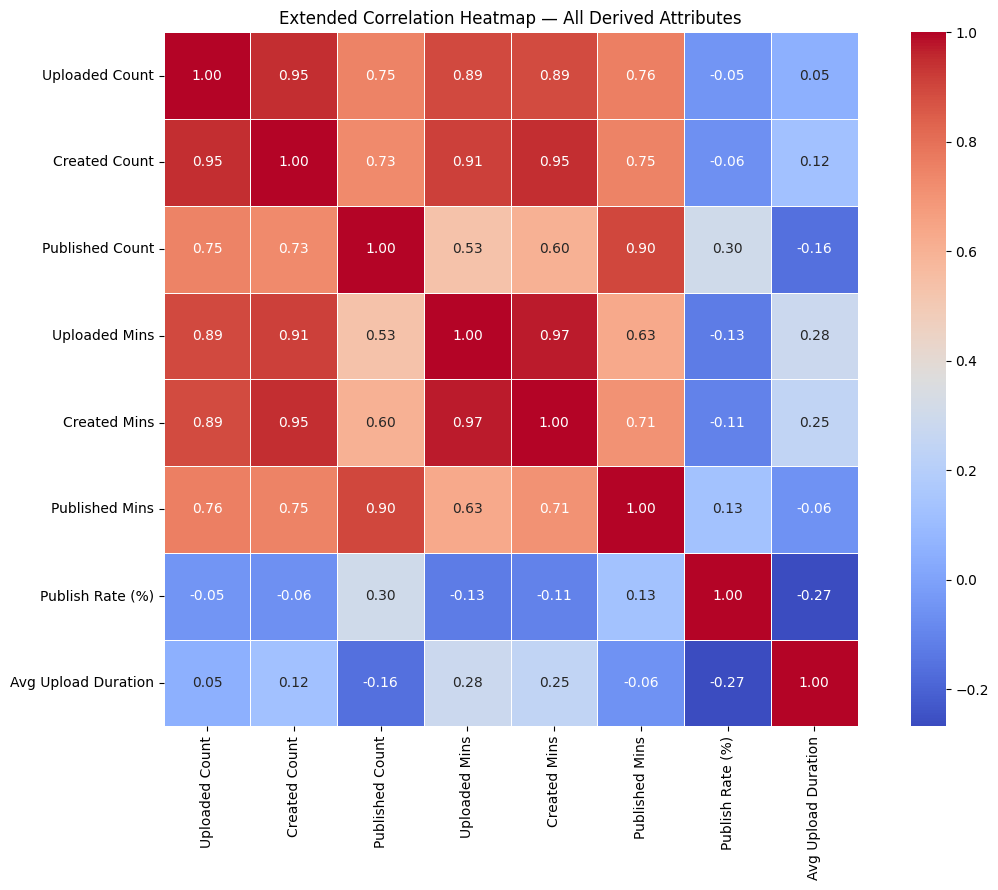

In [11]:
cols = [
    'Uploaded Count', 'Created Count', 'Published Count',
    'Uploaded Mins', 'Created Mins', 'Published Mins',
    'Publish Rate (%)', 'Avg Upload Duration'
]

plt.figure(figsize=(12, 9))
sns.heatmap(
    df[cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)
plt.title('Extended Correlation Heatmap — All Derived Attributes')
plt.tight_layout()
plt.show()

Here we plotted an extended version of our correlation map including the attributes such as publish rate and avg. upload duration

In [13]:
df1

,Headline,Source,Published,Team Name,Type,Uploaded By,Video ID,Published Platform,Published URL
0,Headline_3a11c61b3c1b,https://obfuscated.source.example/a4f0f8276af7...,No,Unknown,news bulletin,Neha,4168417,NaN,NaN
1,Headline_415212ea682f,https://obfuscated.source.example/d2945450bf84...,No,Unknown,news bulletin,Neha,154352428,NaN,NaN
2,Headline_2d82a32f7307,https://obfuscated.source.example/b0d41c47d314...,No,Unknown,news bulletin,Neha,523805444,NaN,NaN
3,Headline_3914d7909c17,https://obfuscated.source.example/c28e8dfd48fb...,No,Unknown,news bulletin,Neha,361444089,NaN,NaN
4,Headline_9b2333056efb,https://obfuscated.source.example/f4c0cf321516...,No,Unknown,news bulletin,Neha,526927388,NaN,NaN
...,...,...,...,...,...,...,...,...,...
14913,Headline_3184e575e0cf,https://obfuscated.source.example/53d28cb85abb...,No,Unknown,debate,vinay singh,633207427,NaN,NaN
14914,Headline_9cc1132b3c9e,https://obfuscated.source.example/55049909812a...,No,Unknown,debate,vinay singh,171239934,NaN,NaN
14915,Headline_5d3f5c5c5a3d,https://obfuscated.source.example/2799c7576755...,No,Unknown,debate,vinay singh,117898983,NaN,NaN
14916,NaN,https://obfuscated.source.example/2799c7576755...,No,Unknown,interview,vinay singh,713121804,NaN,NaN


From this info , we have understood that df1(video_list_data_obfuscated.csv) is the fact table and is the base of all analytics and the dataset df (combined_data(2025-3-1-2026-2-28) by user.csv) is the dimension table on the attribute user.

In [14]:
df1.isnull().sum()

,0
Headline,1274
Source,0
Published,0
Team Name,0
Type,12
Uploaded By,0
Video ID,0
Published Platform,14886
Published URL,14886


There are many values which are missing and we need to apply some data cleaning methods to handle this data

In [16]:
df1_published = df1[df1['Published'] == 'Yes']

print(f"Total records      : {len(df1)}")
print(f"Published records  : {len(df1_published)}")
print(f"Dropped records    : {len(df1) - len(df1_published)}")

Total records      : 14918
Published records  : 100
Dropped records    : 14818


So working on these 100 rows is better than those remaining 14818 which have incomplete data

In [17]:
df1_published

,Headline,Source,Published,Team Name,Type,Uploaded By,Video ID,Published Platform,Published URL
20,Headline_50c78c3bdeae,https://obfuscated.source.example/2cb28865070e...,Yes,Unknown,news bulletin,Adarsh (Frammer),841217136,YouTube,https://obfuscated.published.example/ced5e4b15...
26,Headline_912d6f601f01,https://obfuscated.source.example/8218635b2b50...,Yes,Unknown,news bulletin,Adarsh (Frammer),557914091,YouTube,https://obfuscated.published.example/6e3bf97dc...
721,Headline_c63cc308ce39,https://obfuscated.source.example/631815bc08a0...,Yes,Unknown,interview,Anamika Singh,372228911,YouTube,https://obfuscated.published.example/46de302d0...
726,Headline_1ad853cab5fc,https://obfuscated.source.example/bd7346ddf96a...,Yes,Unknown,interview,Chandan,370073919,YouTube,https://obfuscated.published.example/6510c29a0...
737,Headline_e6f2468975ac,https://obfuscated.source.example/df462dd6ea3e...,Yes,Unknown,interview,Chandan,6549471,YouTube,https://obfuscated.published.example/a31a0eb1b...
...,...,...,...,...,...,...,...,...,...
11619,Headline_97cf9c90a804,https://obfuscated.source.example/3f0448ea83d4...,Yes,Unknown,news bulletin,Harish,648816474,NaN,NaN
11622,Headline_48d709a288ad,https://obfuscated.source.example/167c8a56163c...,Yes,Unknown,news bulletin,QA-Bhargavi,23224466,NaN,NaN
11626,Headline_86d69f9e5529,https://obfuscated.source.example/c462146009c3...,Yes,Unknown,speech,QA-Bhargavi,981533737,NaN,NaN
11716,Headline_f11d20b5e5ed,https://obfuscated.source.example/99e3dfc0fe77...,Yes,Unknown,news bulletin,QA-Bhargavi,776902312,NaN,NaN


In [24]:
df1_published["Uploaded By"]

,Uploaded By
20,Adarsh (Frammer)
26,Adarsh (Frammer)
721,Anamika Singh
726,Chandan
737,Chandan
...,...
11619,Harish
11622,QA-Bhargavi
11626,QA-Bhargavi
11716,QA-Bhargavi


In [26]:
user_counts = df1_published['Uploaded By'].value_counts().reset_index()
user_counts.columns = ['User', 'Count']

print(user_counts)

                                    User  Count
0                                Chandan     19
1                         QA-Purushottam     11
2                                   Neha      9
3                               Abhishek      8
4                                Subhesh      7
5                         Sandeep Belaki      7
6                                 Harish      6
7                             Prithviraj      6
8                            QA-Bhargavi      5
9                     vikas.s@moolya.com      4
10                      Adarsh (Frammer)      3
11                               QA-Amit      3
12                         Anamika Singh      2
13                             Trivendra      2
14                              Alok Rai      2
15  Dheeraj Pareek(QA theveritycorp.com)      2
16                           vinay singh      2
17                              sukhleen      1
18                          Abhishek Sri      1


So now this df1_published basically becomes the effective fact table for our star schema relation.

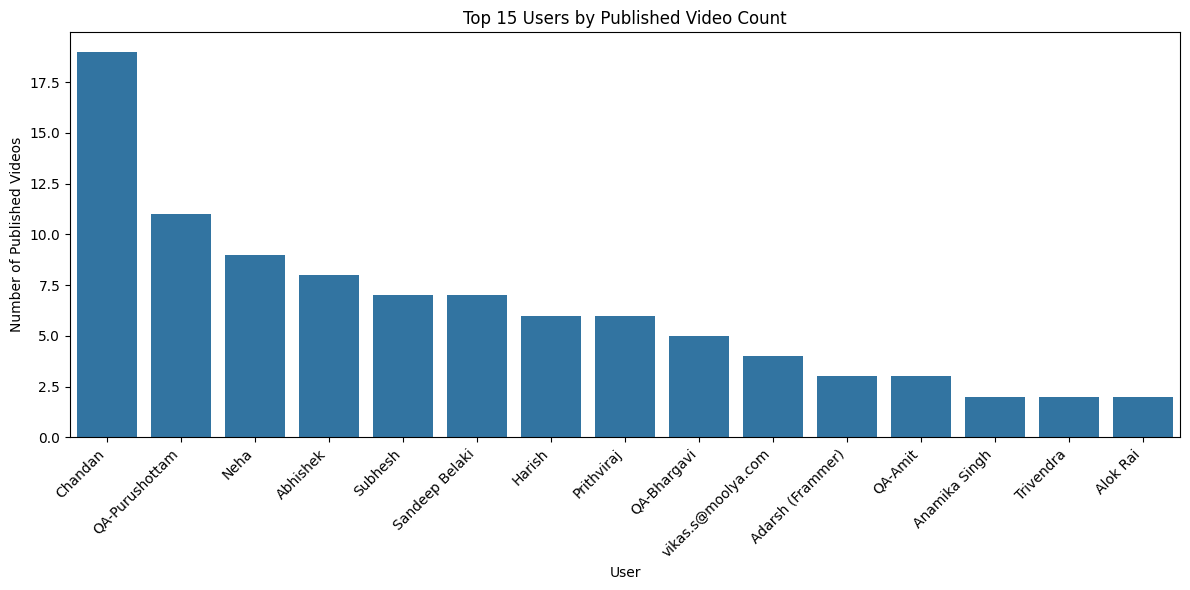

In [31]:
top15_users = user_counts.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top15_users,
    x='User',
    y='Count',
)
plt.title('Top 15 Users by Published Video Count')
plt.xlabel('User')
plt.ylabel('Number of Published Videos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
from_dim = df[['User', 'Published Count']].copy()
from_dim.columns = ['User', 'Published_from_DIM']
from_dim['Published_from_DIM'] = pd.to_numeric(from_dim['Published_from_DIM'])

from_fact = df1_published['Uploaded By'].value_counts().reset_index()
from_fact.columns = ['User', 'Published_from_FACT']

# Merge and compare
comparison = from_dim.merge(from_fact, on='User', how='outer')
comparison['Difference'] = (
    comparison['Published_from_DIM'] - comparison['Published_from_FACT']
)

print(comparison[comparison['Difference'] != 0])

                                User  Published_from_DIM  Published_from_FACT  \
0                                 AB                   0                  NaN   
3                   Adarsh (Frammer)                   5                  3.0   
4                           Alok Rai                   4                  2.0   
6                  Arijit Chatterjee                   0                  NaN   
7                             Arun J                   0                  NaN   
8                            Ashween                   0                  NaN   
9                        Auto Upload                   0                  NaN   
11  Deepika Uniyal (QA testaing.com)                   0                  NaN   
13                  Dheerendra Kumar                   0                  NaN   
14               Divyanshu Dutta Roy                   0                  NaN   
15                            Harish                   7                  6.0   
16                     Kallo

So here we got those users whose values dont match in fact and dimension tables
Important Inference : Every user with a gap shows DIM > FACT, never DIM < FACT
So our DIM and FACT are not in sync. This might happen as some platforms might not have been mentioned in the fact table which were included in the dimension table.

**North Star Metric** : Single most important metric which best captures the core value that product delivers to the users.
With respect to what all we have analysed so far the ***Published Video Count*** is the most important metric which makes it the north star metric.

**Guardian Metric** : It is a metric which checks that while developing north star metric there are no unwanted consequences.
In our case the ***Publish rate*** is the guardian metric.



Active Publishers  : 19
Never Published    : 0
Data Discrepancies : 8
Max Gap            : 2.0


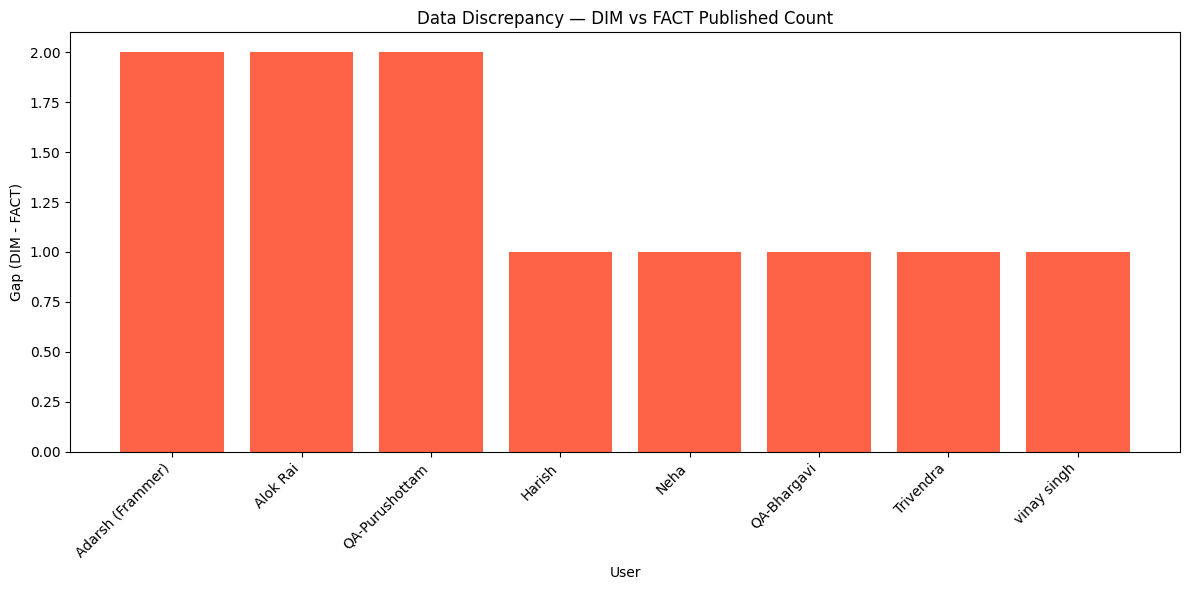

In [33]:
comparison['Published_from_FACT'] = comparison['Published_from_FACT'].fillna(0)
comparison['Difference'] = comparison['Published_from_DIM'] - comparison['Published_from_FACT']
comparison['Status'] = comparison['Published_from_FACT'].apply(
    lambda x: 'Never Published' if x == 0 else 'Active Publisher'
)

# Summary
print("Active Publishers  :", (comparison['Status'] == 'Active Publisher').sum())
print("Never Published    :", (comparison['Status'] == 'Never Publisher').sum())
print("Data Discrepancies :", (comparison['Difference'] > 0).sum())
print("Max Gap            :", comparison['Difference'].max())

# Plot the discrepancy
discrepancy = comparison[comparison['Difference'] > 0].sort_values('Difference', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(discrepancy['User'], discrepancy['Difference'], color='tomato')
plt.title('Data Discrepancy — DIM vs FACT Published Count')
plt.xlabel('User')
plt.ylabel('Gap (DIM - FACT)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
df1_published['Published Platform'] = df1_published['Published Platform'].fillna('Platform Not Recorded')

platform_counts = df1_published['Published Platform'].value_counts().reset_index()
platform_counts.columns = ['Platform', 'Count']
print(platform_counts)

                Platform  Count
0  Platform Not Recorded     68
1                YouTube     25
2                 Shorts      4
3               Facebook      2
4         Facebook-Reels      1


/tmp/ipykernel_625/2187680908.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_published['Published Platform'] = df1_published['Published Platform'].fillna('Platform Not Recorded')


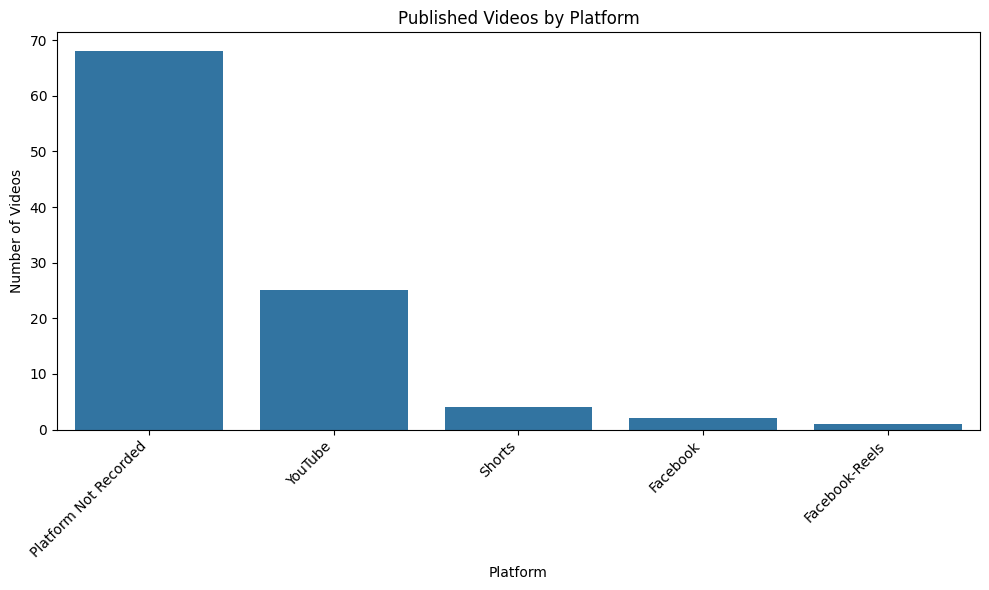

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=platform_counts,
    x='Platform',
    y='Count',
)
plt.title('Published Videos by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [38]:
print(df1_published['Type'].value_counts())

Type
interview           34
news bulletin       33
speech              12
special reports     11
debate               5
discussion-show      3
press conference     2
Name: count, dtype: int64


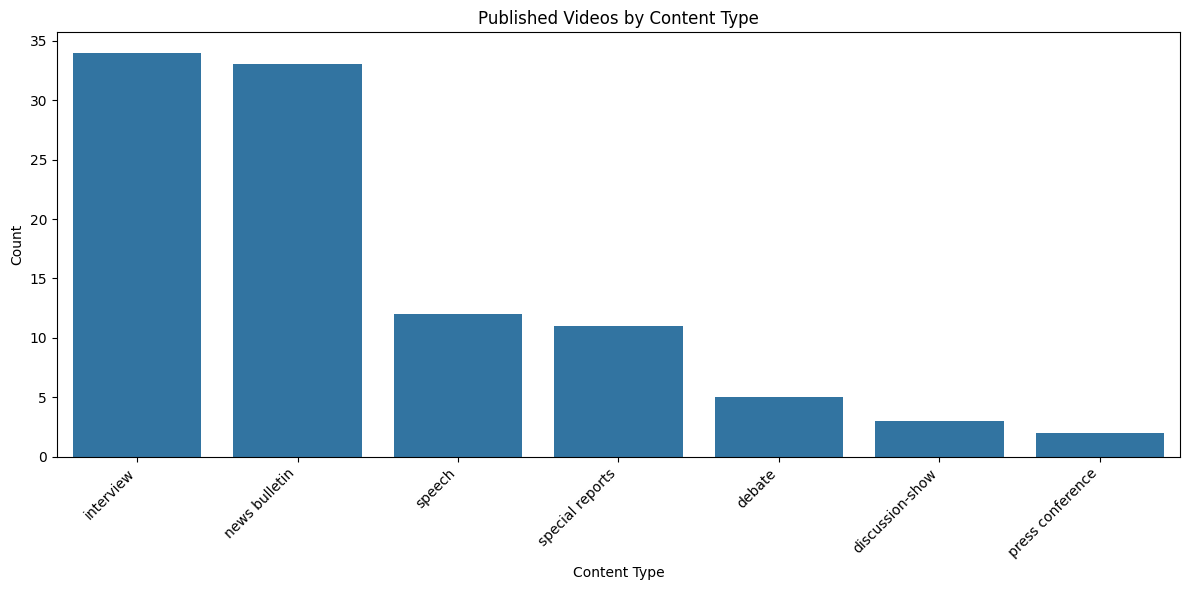

In [39]:
type_counts = df1_published['Type'].value_counts().reset_index()
type_counts.columns = ['Type', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=type_counts,
    x='Type',
    y='Count',
)
plt.title('Published Videos by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()